<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase3/assignment1/NEU_Surface_Defect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement 
You are a junior ML engineer at
SmartForge Manufacturing. The production line images thousands of steel strips
every day. Manual visual inspection is slow, inconsistent, and misses subtle
defects that cause costly downstream failures. The engineering team needs two
things:
1. a model that can identify which type of defect is present, and 
2. evidence that the model is robust enough to handle real production variability
(different lighting, orientations, and surface conditions). Your job is to
build and harden that model using PyTorch.

### Setup 

In [1]:
# imports
import torch 
import torch.nn as nn 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np 
import matplotlib.pyplot as plt 
import copy
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score



In [ ]:
tfm = transforms.Compose([
    transforms.Resize((200,200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

# for vscode/jupyter 
train_ds = datasets.ImageFolder('NEU-DET/train/images',transform=tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images',transform=tfm)






In [6]:
print("Number of images:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

Number of images: 1440
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

In [8]:
test_loader = DataLoader(
    test_ds,        # was train_ds — bug
    batch_size=32,
    shuffle=False   # no need to shuffle validation/test data
)

In [9]:
tfm = transforms.Compose([
    transforms.Resize((200,200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])
train_ds = datasets.ImageFolder('NEU-DET/train/images', transform=tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images', transform=tfm)

print("Number of images:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Number of images: 1440
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [10]:
train_loader

# Part 0 : NN Foundations 

### 1. Implement a simple 2-layer neural network from scratch
using nn.Module no nn.Sequential shortcuts. Define __init__ and forward
explicitly.


Build: 

1. `__init__ `: explicitly defines layers as attribute 
2. `x.view(x.size(0), -1)` inside forward  since images come in as (batch_size, 3, 200, 200) from the DataLoader, and a Linear layer expects a flat 2D input (batch_size, features),flatten every dimension except the batch dimension. 

3. No activation after fc2 the raw logits are returned directly, because nn.CrossEntropyLoss expects raw logits and applies log_softmax internally. Adding a Softmax here yourself would double-apply it and break training.

In [43]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size ):
        super().__init__()

        #layer 1 
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = X.view(X.size(0), -1) 
        X = self.fc1(X)
        X = self.relu(X)
        X = self.fc2(X)
        return X


##### Build
1. `__init__` explicitly defines layers ass attributes

2. x.view(x.size(0),-1 ) the image comes in ass (batch_ize, 3, 200,200), from the dataloader and a linear layer expects a flat 2D input `(batch_size, features)`

3. No activattion after `fc2`: the raw logits are retrned directky, becase nn.CrossEntropy loss expects rawlogits, and applies softmax internally 

### 2. Activation functions: swap ReLU for Sigmoid in your hidden layer and compare convergence over 20 epochs. What do you notice?

In [44]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation = "relu"):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU() if activation == "relu" else nn.Sigmoid()  # to decrease redundanct code
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1) #compress to 2d
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x 

In [45]:
def train_model(model, optimizer, train_loader, criterion, epochs=20):
    loss_hist = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for image, label in train_loader:
            output = model(image)
            loss = criterion(output, label)
            optimizer.zero_grad() # clears the gradients from the previous step ;pt accumulates grad by efault
            loss.backward() #backpropagation
            optimizer.step() #upates the model weights 
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_hist.append(avg_loss)
        print(f"Epochs {epoch+1}/ {epochs}, Loss : {avg_loss}")
    return loss_hist

In [46]:
# model parameters 
input_size = 3 * 200 * 200
# 3 for color RGB and 200x200 is image hxw
hidden_size = 128 
num_classes = len(train_ds.classes)
criterion = nn.CrossEntropyLoss()
epochs = 20 

In [47]:
# for reprodiuciblity ; why always 42--Not always 42; justa  lucky number; can use any number 
torch.manual_seed(42 )
# for relu 
model_relu = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "relu")

In [48]:
#reset seed to the same vlaue so model_sigmoid gets identical initital weights 
torch.manual_seed(42)
model_sigmoid = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "sigmoid")

In [49]:
# seperate optimizer for each model, adam tracks per-parameter state, so eacch model needs its own instance 
opt_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
opt_sigmoid = torch.optim.Adam(model_sigmoid.parameters(), lr=0.001)


In [50]:
print("Training with ReLU.......")
loss_relu = train_model(model_relu, opt_relu, train_loader, criterion, epochs)


Training with ReLU.......
Epochs 1/ 20, Loss : 14.745438967810736
Epochs 2/ 20, Loss : 8.657253779305352
Epochs 3/ 20, Loss : 6.463003412882487
Epochs 4/ 20, Loss : 5.278574249479505
Epochs 5/ 20, Loss : 3.042806702189975
Epochs 6/ 20, Loss : 2.956722068786621
Epochs 7/ 20, Loss : 3.8283591588338215
Epochs 8/ 20, Loss : 4.0359620852602855
Epochs 9/ 20, Loss : 2.1650445030795202
Epochs 10/ 20, Loss : 1.726602178812027
Epochs 11/ 20, Loss : 1.5394811507728365
Epochs 12/ 20, Loss : 1.5329998119009867
Epochs 13/ 20, Loss : 1.2566487060652838
Epochs 14/ 20, Loss : 2.36754211584727
Epochs 15/ 20, Loss : 1.3318881195452479
Epochs 16/ 20, Loss : 0.8513764441013336
Epochs 17/ 20, Loss : 0.8888723303874334
Epochs 18/ 20, Loss : 1.1629293660322826
Epochs 19/ 20, Loss : 1.1246533311075635
Epochs 20/ 20, Loss : 0.8246496273411645


In [51]:
print("Training with sigmoid........")
loss_sigmoid = train_model(model_sigmoid, opt_sigmoid, train_loader, criterion, epochs)

Training with sigmoid........
Epochs 1/ 20, Loss : 1.6509633170233833
Epochs 2/ 20, Loss : 1.5487802240583632
Epochs 3/ 20, Loss : 1.5068914863798353
Epochs 4/ 20, Loss : 1.4785277605056764
Epochs 5/ 20, Loss : 1.4741892947090998
Epochs 6/ 20, Loss : 1.4461919811036852
Epochs 7/ 20, Loss : 1.4169582658343844
Epochs 8/ 20, Loss : 1.4069631576538086
Epochs 9/ 20, Loss : 1.3878456777996486
Epochs 10/ 20, Loss : 1.3770901891920302
Epochs 11/ 20, Loss : 1.3592094315422907
Epochs 12/ 20, Loss : 1.3546625667148167
Epochs 13/ 20, Loss : 1.3387040535608927
Epochs 14/ 20, Loss : 1.3158487108018664
Epochs 15/ 20, Loss : 1.304413980907864
Epochs 16/ 20, Loss : 1.2901036977767943
Epochs 17/ 20, Loss : 1.2918552902009752
Epochs 18/ 20, Loss : 1.2972790718078613
Epochs 19/ 20, Loss : 1.2890637556711833
Epochs 20/ 20, Loss : 1.2961081796222262


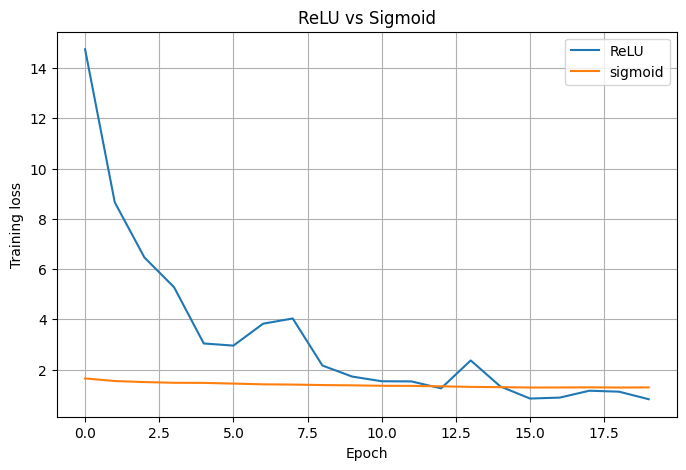

In [52]:
plt.figure(figsize=(8,5))
plt.plot(loss_relu, label="ReLU")
plt.plot(loss_sigmoid, label= "sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("ReLU vs Sigmoid")
plt.grid()
plt.legend()
plt.show()

### Observations
ReLU converged faster and reach a lower loss within 20 epochs 
Sigmoid converged more lowly, and the loss curve look almost flat and at last it dropped littlebit 

whay did it happened 
1. vanishing gradients : sigmoid squashes any intput to `(0,1)`. Its derivative hass a max value of only 0.25(at x =0), and get close to 0 when the input is large or large negative

2. ReLU avoud this for active neurons.ReLU's derivative is either 0(for negative )or 1(for+ve), no squashing and shriniking gradeints



### 3.Loss function choice: train with nn.CrossEntropyLoss. Why is this preferred over nn.MSELoss for multi-class defect classification?

1. It fits the problem. `CrossEntropyLoss` compares predicted probablities to the correct class. MSE compares raw numbers, it doeesn't understand categories so it treats defect labels as if they had numeric distance between them

2. It learns faster when the model is wrong:`CrossEntropyLoss` gives a strong gradient(correction signals) when the prediction is confidently wrong, pusshing the model to fix itself quickly.MSEs gradient shrinks to almost zero in that same ssituation, so the model barely learns from its biggest mistakes 

3. It's the standatd, numerically stable choiocs. CrossEntropyLoss orks directly on raw model output (logits) and handles the math safely under the hood. MSE would need extra manual steps and doesnot give better results 

### 4.Optimizer comparison: train the same network three times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss curves on one graph. Which converges fastest? Estimate the GPU memory each optimizer requires for this model.


In [53]:
# using the same Simple2LayerNN 
base_model = Simple2LayerNN(input_size, hidden_size, num_classes)
# deepcopy creates a completely independent copy of the model — including its own separate weight tensors in memory, not references to the original
model_sgd = copy.deepcopy(base_model)
model_sgd_momentum = copy.deepcopy(base_model)
model_adam = copy.deepcopy(base_model)

opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr =0.001)
opt_sgd_mom= torch.optim.SGD(model_sgd_momentum.parameters(), lr =0.001, momentum=0.9)
opt_adam = torch.optim.Adam(model_adam.parameters(), lr =0.001)

In [54]:
print("Training with SGD...")
loss_sgd = train_model(model_sgd, opt_sgd, train_loader, criterion, epochs)

Training with SGD...
Epochs 1/ 20, Loss : 1.5584679947959053
Epochs 2/ 20, Loss : 1.439536256260342
Epochs 3/ 20, Loss : 1.3726655006408692
Epochs 4/ 20, Loss : 1.3210775481330024
Epochs 5/ 20, Loss : 1.2820634020699395
Epochs 6/ 20, Loss : 1.2466225730048286
Epochs 7/ 20, Loss : 1.2178347084257337
Epochs 8/ 20, Loss : 1.1875419947836134
Epochs 9/ 20, Loss : 1.1616440216700237
Epochs 10/ 20, Loss : 1.140227406554752
Epochs 11/ 20, Loss : 1.118576576974657
Epochs 12/ 20, Loss : 1.0965880831082662
Epochs 13/ 20, Loss : 1.07972248395284
Epochs 14/ 20, Loss : 1.06197046968672
Epochs 15/ 20, Loss : 1.0475518756442599
Epochs 16/ 20, Loss : 1.0290686342451307
Epochs 17/ 20, Loss : 1.014541757106781
Epochs 18/ 20, Loss : 1.0023573160171508
Epochs 19/ 20, Loss : 0.9874157309532166
Epochs 20/ 20, Loss : 0.9744278179274665


In [55]:
print("Training with SGD + Momentum...")
losss_sgd_mom = train_model(model_sgd_momentum, opt_sgd_mom, train_loader, criterion, epochs)

Training with SGD + Momentum...
Epochs 1/ 20, Loss : 1.5161046610938178
Epochs 2/ 20, Loss : 1.2324362887276543
Epochs 3/ 20, Loss : 1.0666076329019334
Epochs 4/ 20, Loss : 0.9761975394354926
Epochs 5/ 20, Loss : 0.9143653710683187
Epochs 6/ 20, Loss : 0.8093807445632086
Epochs 7/ 20, Loss : 0.7729626172118716
Epochs 8/ 20, Loss : 0.7301199244128334
Epochs 9/ 20, Loss : 0.6634182400173612
Epochs 10/ 20, Loss : 0.6060724172327253
Epochs 11/ 20, Loss : 0.5780071543322669
Epochs 12/ 20, Loss : 0.5266939017507765
Epochs 13/ 20, Loss : 0.49279560446739196
Epochs 14/ 20, Loss : 0.48521424233913424
Epochs 15/ 20, Loss : 0.4828737450970544
Epochs 16/ 20, Loss : 0.4596199376715554
Epochs 17/ 20, Loss : 0.4168564650747511
Epochs 18/ 20, Loss : 0.39517435299025644
Epochs 19/ 20, Loss : 0.3843770891427994
Epochs 20/ 20, Loss : 0.40708726114696925


In [56]:
print("Traiing with adam..")
losss_adam = train_model(model_adam, opt_adam, train_loader, criterion, epochs)

Traiing with adam..
Epochs 1/ 20, Loss : 11.550204218758477
Epochs 2/ 20, Loss : 7.712260225084093
Epochs 3/ 20, Loss : 5.805428674485948
Epochs 4/ 20, Loss : 4.397087738249037
Epochs 5/ 20, Loss : 2.900029600991143
Epochs 6/ 20, Loss : 3.292903631263309
Epochs 7/ 20, Loss : 3.3245485610432093
Epochs 8/ 20, Loss : 2.178766002919939
Epochs 9/ 20, Loss : 2.0760814911789365
Epochs 10/ 20, Loss : 2.4699121945434146
Epochs 11/ 20, Loss : 1.0611423157983355
Epochs 12/ 20, Loss : 1.2675506909688314
Epochs 13/ 20, Loss : 1.8005775133768718
Epochs 14/ 20, Loss : 1.5055747270584106
Epochs 15/ 20, Loss : 1.2431044773923026
Epochs 16/ 20, Loss : 1.0442866692940393
Epochs 17/ 20, Loss : 1.048249312904146
Epochs 18/ 20, Loss : 0.974412226345804
Epochs 19/ 20, Loss : 0.9177880091799631
Epochs 20/ 20, Loss : 0.808514756626553


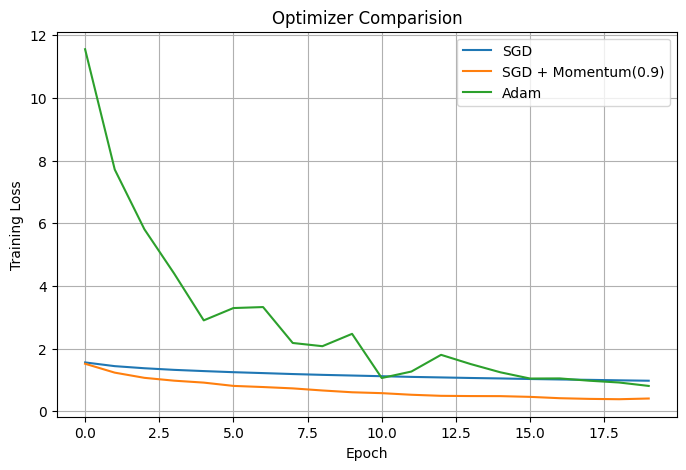

In [57]:
plt.figure(figsize = (8,5))
plt.plot(loss_sgd, label = "SGD")
plt.plot(losss_sgd_mom, label = "SGD + Momentum(0.9)")
plt.plot(losss_adam, label = "Adam")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparision")
plt.grid(True)
plt.legend()
plt.show()

In [58]:
# GPU memeory Esitmation

num_params = sum(p.numel() for p in model_sgd.parameters())
bytes_per_param = 4

print(f"Params: {num_params:,}")
print(f"SGD extra memory: {num_params * bytes_per_param / 1e6:.2f} MB")           # gradients only
print(f"SGD+Momentum extra memory: {num_params * bytes_per_param * 2 / 1e6:.2f} MB")  # + momentum buffer
print(f"Adam extra memory: {num_params * bytes_per_param * 3 / 1e6:.2f} MB")      # + m + v

Params: 15,360,902
SGD extra memory: 61.44 MB
SGD+Momentum extra memory: 122.89 MB
Adam extra memory: 184.33 MB


Adam Spiked and oscilated instead of converging smoothly, while SGD and SGD + momentum decresed steadilt but slowly. This is likely because Adam's adaptive learning rate overreacted to the large, unnormalized input 

### 5. Training stability: add nn.BatchNorm1d after your hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation loss. Explain why the technique produces the effect you observe.

In [59]:
class Simple2LayerNN_BN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, p =0.3):
        super().__init__()
        self.fc1 =nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.fc2(x)
        return x 

In [60]:
class Simple2LayerNN_Dropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, p =0.3):
        super().__init__()
        self.fc1 =nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x 

In [61]:
def train_with_val(model, optimizer,train_loader, val_loader, criterion , epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()  #BN use batch stats, Dropout is active
        running_loss = 0.0
        for image, label in train_loader:
            output = model(image)
            loss = criterion(output, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)  # BUG: avg_loss was never computed before print
        train_losses.append(avg_loss)
        

        model.eval() 
        val_loss = 0.0
        with torch.no_grad():
            for image, label in val_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    return train_losses, val_losses

In [62]:
model_bn = Simple2LayerNN_BN(input_size, hidden_size, num_classes)
opt_bn = torch.optim.Adam(model_bn.parameters(), lr=0.001)
train_loss_bn, val_loss_bn = train_with_val(model_bn, opt_bn, train_loader, test_loader, criterion, epochs=20)

Epoch 1/20, Train Loss: 1.5766, Val Loss: 1.6684
Epoch 2/20, Train Loss: 1.2971, Val Loss: 1.4953
Epoch 3/20, Train Loss: 1.1624, Val Loss: 1.3857
Epoch 4/20, Train Loss: 1.0895, Val Loss: 1.3406
Epoch 5/20, Train Loss: 0.9921, Val Loss: 1.3614
Epoch 6/20, Train Loss: 0.9264, Val Loss: 1.3274
Epoch 7/20, Train Loss: 0.8584, Val Loss: 1.3262
Epoch 8/20, Train Loss: 0.8224, Val Loss: 1.2430
Epoch 9/20, Train Loss: 0.7616, Val Loss: 1.1748
Epoch 10/20, Train Loss: 0.7337, Val Loss: 1.2579
Epoch 11/20, Train Loss: 0.7048, Val Loss: 1.1436
Epoch 12/20, Train Loss: 0.6592, Val Loss: 1.1037
Epoch 13/20, Train Loss: 0.6365, Val Loss: 1.2262
Epoch 14/20, Train Loss: 0.5950, Val Loss: 1.4190
Epoch 15/20, Train Loss: 0.5764, Val Loss: 1.1957
Epoch 16/20, Train Loss: 0.5623, Val Loss: 1.2859
Epoch 17/20, Train Loss: 0.5251, Val Loss: 1.2668
Epoch 18/20, Train Loss: 0.4936, Val Loss: 1.0626
Epoch 19/20, Train Loss: 0.5064, Val Loss: 1.2215
Epoch 20/20, Train Loss: 0.5204, Val Loss: 1.1184


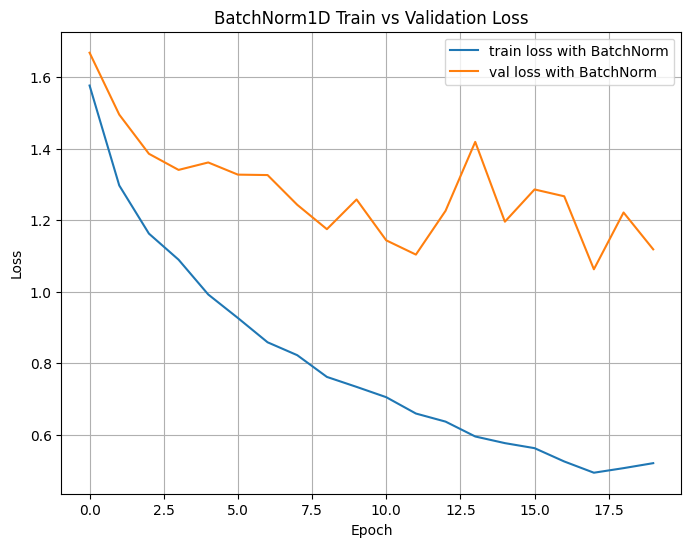

In [63]:
plt.figure(figsize= (8,6))
plt.plot(train_loss_bn, label="train loss with BatchNorm")
plt.plot(val_loss_bn, label="val loss with BatchNorm")
plt.title("BatchNorm1D Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [64]:
model_dropout = Simple2LayerNN_Dropout(input_size, hidden_size, num_classes)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.001)
train_loss_dropout, val_loss_dropout = train_with_val(model_dropout, opt_dropout, train_loader, test_loader, criterion, epochs=20)

Epoch 1/20, Train Loss: 17.5726, Val Loss: 12.0063
Epoch 2/20, Train Loss: 8.6678, Val Loss: 12.9023
Epoch 3/20, Train Loss: 7.5451, Val Loss: 16.2395
Epoch 4/20, Train Loss: 7.3375, Val Loss: 10.2079
Epoch 5/20, Train Loss: 5.2957, Val Loss: 5.6184
Epoch 6/20, Train Loss: 4.5035, Val Loss: 10.2558
Epoch 7/20, Train Loss: 3.3804, Val Loss: 4.4276
Epoch 8/20, Train Loss: 2.4964, Val Loss: 6.4597
Epoch 9/20, Train Loss: 3.2676, Val Loss: 5.3657
Epoch 10/20, Train Loss: 2.6551, Val Loss: 3.6245
Epoch 11/20, Train Loss: 1.8832, Val Loss: 3.3665
Epoch 12/20, Train Loss: 1.4008, Val Loss: 4.3555
Epoch 13/20, Train Loss: 1.3377, Val Loss: 4.0922
Epoch 14/20, Train Loss: 1.2703, Val Loss: 3.9309
Epoch 15/20, Train Loss: 1.4194, Val Loss: 5.2559
Epoch 16/20, Train Loss: 1.2096, Val Loss: 4.6554
Epoch 17/20, Train Loss: 1.0720, Val Loss: 2.9071
Epoch 18/20, Train Loss: 0.9590, Val Loss: 3.5979
Epoch 19/20, Train Loss: 0.9011, Val Loss: 3.4980
Epoch 20/20, Train Loss: 0.7944, Val Loss: 2.1069


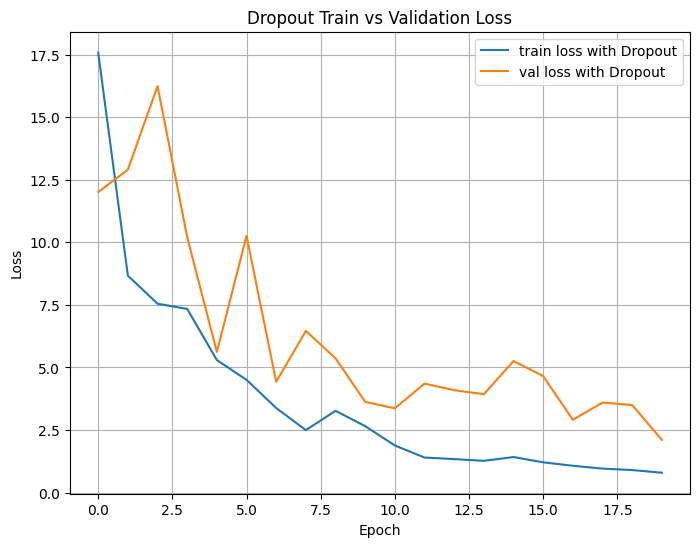

In [65]:
plt.figure(figsize= (8,6))
plt.plot(train_loss_dropout, label="train loss with Dropout")
plt.plot(val_loss_dropout, label="val loss with Dropout")
plt.title("Dropout Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Part 1: Part A: Defect Type Classifier


### 1.Load the NEU dataset using torchvision.datasets.ImageFolder and torch.utils.data.DataLoader. How many images per class? What are the image dimensions?

In [66]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import torch.optim as optim  

tfm = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

In [67]:
train_ds = datasets.ImageFolder("NEU-DET/train/images", transform=tfm)
test_ds = datasets.ImageFolder("NEU-DET/validation/images", transform=tfm)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=True)

print("Numberr of training images:", len(train_ds))
print("Classess:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

Numberr of training images: 1440
Classess: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [68]:
# count images per class 
labels  = []
for _, label in train_ds.samples:
    labels.append(label)
print(Counter(labels))

Counter({0: 240, 1: 240, 2: 240, 3: 240, 4: 240, 5: 240})


In [69]:
# check image dimensions,
sample_img, sample_label = train_ds[0]
print("Image shape(after transform)", sample_img.shape)

Image shape(after transform) torch.Size([3, 200, 200])


### 2.Normalise pixel values using torchvision.transforms.Normalize. Why is normalisation important before training a CNN?

In [70]:
# already been done above 
transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

#### Why this mattsers for training a CNN
Normalization centers pixel values around zero and scales them to a consistent range, which stabilizes gradient updates, prevents activation saturation, and reduces the network;s sensitivity to eaw brightness differnces betweeen images, all of which lead to faster, more stable CNN training...

### 3.Build a CNN classifier using nn.Module with at least: Conv2d → ReLU → MaxPool2d (×2) → Flatten → Linear output for 6 classes.

In [71]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # block 1:
        #  input channels : 3 (RGB): 
        # out_channel :: 16 features; 16 filters means the layer learns 16 differnt low-level pattern detectores(edge, grads,)
        # kernal  = 3 : 3x3 is docs standard
        # padding = 1 ; with a 3x3 kernall ,padding =1 keeps the output spatial size equal to the input size
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # max pool  reduces spatial size divided by 2 : 200->100->50; and max pooling picks the strongest activation in each 2×2 region, 
        # so small shifts/rotations in where a defect 
        # appears in the image don't drastically change the output. 
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32*50*50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.flatten(x)
        x = self.fc(x)
        return x
    
# what and whys not covered in comments 
# why increase channel from 16 to 32 in conv2(not keep 16, or drop to 8)
#  as a spatial reosultion shrinks(pooling), it's standard practice to increase channel depth
# the netweok represents more combinations of block 1 without exploing the parmemeters cout 


# why flatten thn linear at end(why not another conv)
# clasification requires a fixed lenght vector mapped to num_classes scores
# conv layers preserver spatial structure(to detect where something is );
 # but final task is just "what class is this image" -> need to collapse to one vector


# why no activation after final fc 
# nn.CRossEntropyLoss expects raw logits and applites log_softmax inernally
# adding softmax here would double apply it and break the loss computaiotn


### 4. Write a full PyTorch training loop: zero_grad() → forward() → CrossEntropyLoss → backward() → optimizer.step(). Train for 15 epochs.

In [72]:
model = CNN(num_classes=len(train_ds.classes))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [73]:
epochs = 15
train_losses = []
val_losses = []
train_acc = []
val_acc = []

for epoch in range(epochs):
    # training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()          # clears gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)  # computes CrossEntropyLoss
        loss.backward()                # backward pass; compute gradients
        optimizer.step()               # update weights

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  # predicted class = highest logit
        correct += (predicted == labels).sum().item()   
        total += labels.size(0)                          

    train_losses.append(running_loss / len(train_loader))
    train_acc.append(correct / total)

    # validation
    model.eval()  # model in eval state
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()  # true positives count
            val_total += labels.size(0)

    val_losses.append(val_loss / len(test_loader))
    val_acc.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} || "
          f"Train loss: {train_losses[-1]:.4f}, Train acc: {train_acc[-1]:.4f} | "
          f"Val loss: {val_losses[-1]:.4f}, Val acc: {val_acc[-1]:.4f}")

Epoch 1/15 || Train loss: 1.4129, Train acc: 0.5569 | Val loss: 1.1367, Val acc: 0.5972
Epoch 2/15 || Train loss: 0.5196, Train acc: 0.8097 | Val loss: 0.8066, Val acc: 0.7000
Epoch 3/15 || Train loss: 0.3314, Train acc: 0.8875 | Val loss: 0.6811, Val acc: 0.7194
Epoch 4/15 || Train loss: 0.2516, Train acc: 0.9181 | Val loss: 0.3087, Val acc: 0.8944
Epoch 5/15 || Train loss: 0.1998, Train acc: 0.9285 | Val loss: 0.3363, Val acc: 0.8583
Epoch 6/15 || Train loss: 0.1760, Train acc: 0.9500 | Val loss: 0.3499, Val acc: 0.8500
Epoch 7/15 || Train loss: 0.1689, Train acc: 0.9479 | Val loss: 0.3002, Val acc: 0.8778
Epoch 8/15 || Train loss: 0.1217, Train acc: 0.9618 | Val loss: 0.2772, Val acc: 0.8861
Epoch 9/15 || Train loss: 0.1060, Train acc: 0.9736 | Val loss: 0.4069, Val acc: 0.8528
Epoch 10/15 || Train loss: 0.0943, Train acc: 0.9771 | Val loss: 0.2268, Val acc: 0.9056
Epoch 11/15 || Train loss: 0.0843, Train acc: 0.9778 | Val loss: 0.2340, Val acc: 0.8861
Epoch 12/15 || Train loss: 0.0

### 5. Plot training vs. validation accuracy and loss. Is the model overfitting? At what epoch does it start?

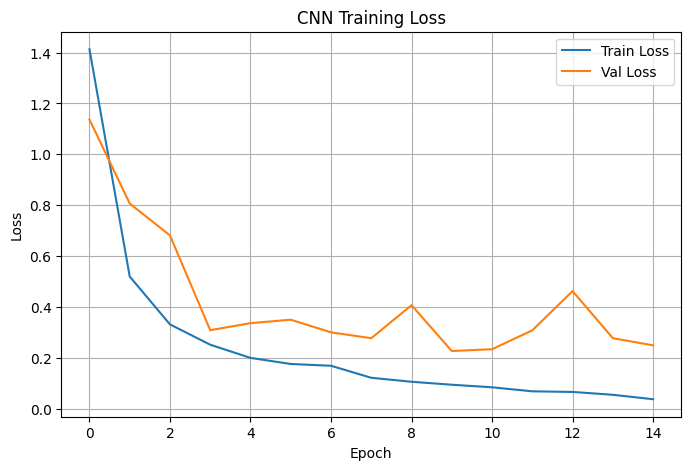

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

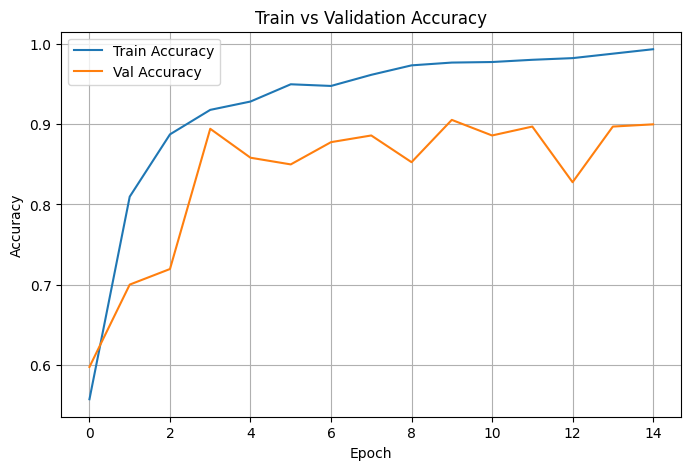

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Overfitting begins around epoch 3–4 — that's where val loss hits its minimum and train/val curves start diverging. After that point:

### 6. Per-class evaluation: which defect type has the lowest F1 score on the test set? Look at misclassified examples — why might crazing and patches be confused?
 

                 precision    recall  f1-score   support

        crazing      0.946     0.883     0.914        60
      inclusion      0.806     0.900     0.850        60
        patches      0.864     0.950     0.905        60
 pitted_surface      0.963     0.867     0.912        60
rolled-in_scale      0.952     1.000     0.976        60
      scratches      0.889     0.800     0.842        60

       accuracy                          0.900       360
      macro avg      0.903     0.900     0.900       360
   weighted avg      0.903     0.900     0.900       360



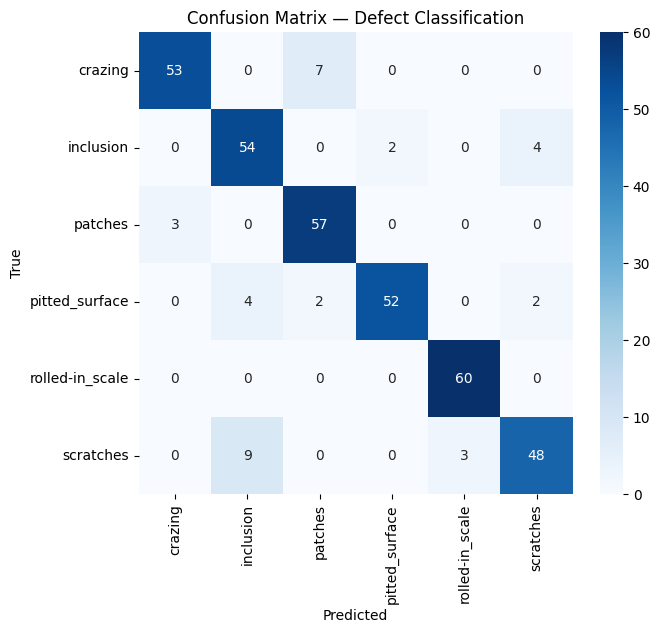

In [76]:
import seaborn as sns
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# pper-class precision, recall, F1
print(classification_report(all_labels, all_preds, target_names=train_ds.classes, digits=3))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Defect Classification")
plt.show()

In [77]:
f1_per_class = f1_score(all_labels, all_preds, average=None)
for cls_name, f1 in zip(train_ds.classes, f1_per_class):
    print(f"{cls_name}: F1 = {f1}")

lowest_idx = np.argmin(f1_per_class)
print(f"Lowest F1: {train_ds.classes[lowest_idx]} ({f1_per_class[lowest_idx]})")

crazing: F1 = 0.9137931034482759
inclusion: F1 = 0.8503937007874016
patches: F1 = 0.9047619047619048
pitted_surface: F1 = 0.9122807017543859
rolled-in_scale: F1 = 0.975609756097561
scratches: F1 = 0.8421052631578947
Lowest F1: scratches (0.8421052631578947)


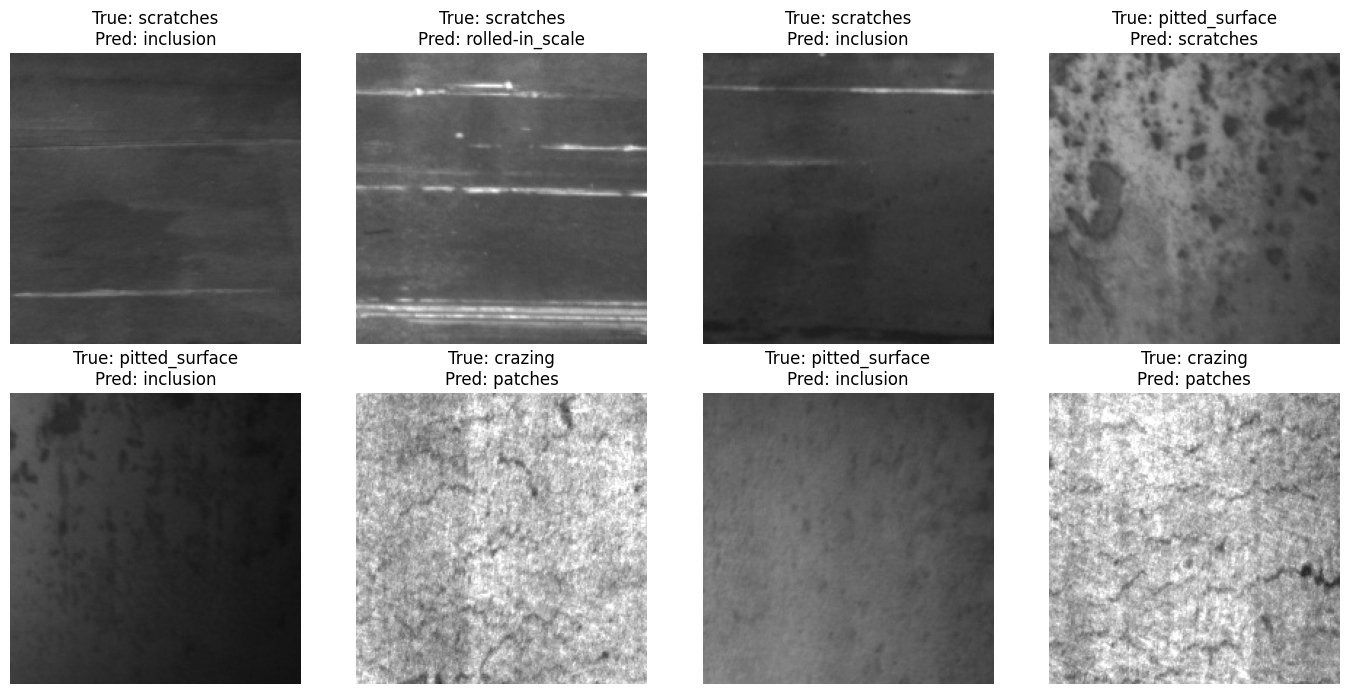

In [78]:
model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        wrong_mask = predicted != labels
        for i in range(len(labels)):
            if wrong_mask[i]:
                misclassified.append((images[i], labels[i].item(), predicted[i].item()))
        if len(misclassified) >= 8:  # grab a handful
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (img, true_label, pred_label) in zip(axes.flatten(), misclassified[:8]):
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5) + 0.5  # undo normalization (mean=0.5, std=0.5)
    ax.imshow(img_np)
    ax.set_title(f"True: {train_ds.classes[true_label]}\nPred: {train_ds.classes[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Part B: Model Hardening
The production line is messy.
Defects appear at any angle, under variable lighting, and at different
positions in the frame. A model trained only on clean, centred images will fail
in deployment.


### 7. Data augmentation: add transforms for the training setonly — RandomHorizontalFlip, RandomRotation(15), RandomCrop(180). Do NOTaugment the validation/test set. Why?


In [79]:
train_tfm = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),
    transforms.Resize((200, 200)),  # resize back after crop so shapes stay consistent
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [80]:
# Validation- NO augmentation
val_tfm = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [81]:
train_ds = datasets.ImageFolder('NEU-DET/train/images', transform=train_tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images', transform=val_tfm)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Validaidation/test data must represent, unaltered eg the model will see in deploymnet. Augumenation is a training-only trick to atrifically expand variety and prevent overfitting,  applying it to val data would:

1. Make val metrics incosistent/random 
2. no reflect real-world estimation 
3. risk destryoing label validity in worst case 

### 8.Batch normalisation: add nn.BatchNorm2d after each Conv2d layer. Retrain. How do the loss curves change compared to Part A?Explain the mechanism.

In [82]:
class CNN_BN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
       
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        nn.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32*50*50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.flatten(x)
        x = self.fc(x)
        return x
  

In [83]:
model_bn = CNN_BN(num_classes=len(train_ds.classes))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_bn.parameters(), lr=0.001)


In [84]:
epochs = 15
train_losses_bn, val_loss_bn = [], []
train_acc_bn, val_acc_bn = [], []

for epoch in range(epochs):
    model_bn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_bn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_losses_bn.append(running_loss / len(train_loader))
    train_acc_bn.append(correct / total)

    model_bn.eval()
    val_loss = 0.0
    val_correct = 0 
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model_bn(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss_bn.append(val_loss / len(test_loader))
    val_acc_bn.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} || "
          f"Train Loss: {train_losses_bn[-1]}, Train Acc: {train_acc_bn[-1]} | "
          f"Val Loss: {val_loss_bn[-1]}, Val Acc: {val_acc_bn[-1]}")




Epoch 1/15 || Train Loss: 1.4887788481182522, Train Acc: 0.45625 | Val Loss: 1.5152997175852458, Val Acc: 0.4638888888888889
Epoch 2/15 || Train Loss: 1.050491295920478, Train Acc: 0.6256944444444444 | Val Loss: 1.3248092780510585, Val Acc: 0.5055555555555555
Epoch 3/15 || Train Loss: 0.8617293251885308, Train Acc: 0.7090277777777778 | Val Loss: 1.090180513759454, Val Acc: 0.5527777777777778
Epoch 4/15 || Train Loss: 0.6920971552530925, Train Acc: 0.7756944444444445 | Val Loss: 1.007897427926461, Val Acc: 0.5777777777777777
Epoch 5/15 || Train Loss: 0.5481628861692217, Train Acc: 0.8243055555555555 | Val Loss: 1.1543525258700054, Val Acc: 0.5805555555555556
Epoch 6/15 || Train Loss: 0.4845831917391883, Train Acc: 0.8354166666666667 | Val Loss: 1.005472432821989, Val Acc: 0.7277777777777777
Epoch 7/15 || Train Loss: 0.42661865254243214, Train Acc: 0.8597222222222223 | Val Loss: 0.9214698903573056, Val Acc: 0.5666666666666667
Epoch 8/15 || Train Loss: 0.386229114068879, Train Acc: 0.875 

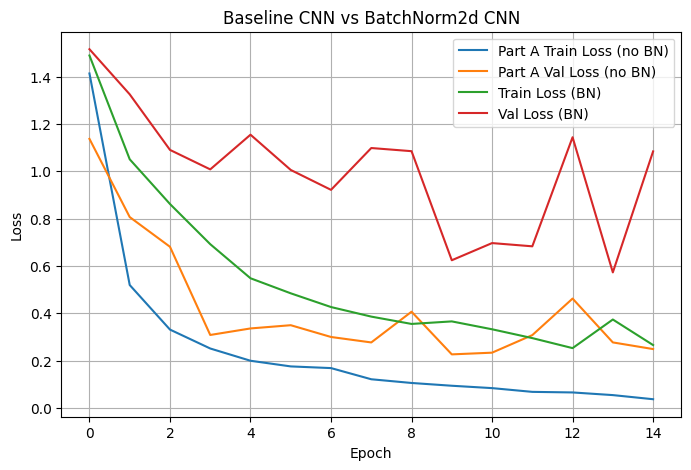

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Part A Train Loss (no BN)")
plt.plot(val_losses, label="Part A Val Loss (no BN)")
plt.plot(train_losses_bn, label="Train Loss (BN)")
plt.plot(val_loss_bn, label="Val Loss (BN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN vs BatchNorm2d CNN")
plt.legend()
plt.grid(True)
plt.show()

### 9.Dropout: add nn.Dropout(0.4) before the final Linear layer. How does this affect overfitting? What is dropout doing during training vs. inference?

In [86]:
class CNN_Dropout(nn.Module):
    def __init__(self, num_classes, p =0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p)
        self.fc = nn.Linear(32*50*50, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [87]:
def train_with_val(model, optimizer, train_loader, val_loader, criterion, epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for image, label in train_loader:
            optimizer.zero_grad()
            output = model(image)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for image, label in val_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss}, Val Loss: {avg_val_loss}")
    return train_losses, val_losses

In [88]:
model_dropout = CNN_Dropout(num_classes=len(train_ds.classes))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=0.001)

train_losses_do, val_loss_do = train_with_val(
    model_dropout, optimizer, train_loader, test_loader, criterion, epochs=15
)

Epoch 1/15, Train Loss: 1.3008857011795043, Val Loss: 1.6601481921970844
Epoch 2/15, Train Loss: 0.848532481988271, Val Loss: 1.0722865164279938
Epoch 3/15, Train Loss: 0.625100337796741, Val Loss: 1.758555930107832
Epoch 4/15, Train Loss: 0.4882718351152208, Val Loss: 1.11931087449193
Epoch 5/15, Train Loss: 0.3805945505698522, Val Loss: 1.0531492359781016
Epoch 6/15, Train Loss: 0.3425342344575458, Val Loss: 1.6827634274959564
Epoch 7/15, Train Loss: 0.347505590154065, Val Loss: 0.8433107292900482
Epoch 8/15, Train Loss: 0.3541298213932249, Val Loss: 1.0272973156534135
Epoch 9/15, Train Loss: 0.28396370112895963, Val Loss: 1.1818685890175402
Epoch 10/15, Train Loss: 0.3656728012694253, Val Loss: 2.0716237034648657
Epoch 11/15, Train Loss: 0.2862714444597562, Val Loss: 1.5379954878881108
Epoch 12/15, Train Loss: 0.26160487830638884, Val Loss: 0.8512990612507565
Epoch 13/15, Train Loss: 0.2568717317448722, Val Loss: 1.0977827701717615
Epoch 14/15, Train Loss: 0.2288418397307396, Val Lo

#### How does Dropout affect overfitting
Dropout randomly zeroes out 40% of the flattened features on every training step. This prevents the final Linear layer from becoming overly dependent on any single feature or neuron,since that neuron might be "dropped" on the next batch, the network is forced to spread useful information across many neurons rather than memorizing training-specific patterns through a few highly-tuned ones.

**What is Dropout doing during training vs. inference?**

- During training (model.train()):

On each forward pass, each unit is independently zeroed with probability p (here 0.4)
The units that survive are scaled up by 1/(1-p)  this keeps the expected total activation roughly the same as without dropout
Effectively, a different random "thinned" sub-network is trained on every batch,like training an ensemble of many smaller networks that share weights

- During inference (model.eval()):

Dropout is turned off completely, every unit is used, nothing is zeroed
No scaling is applied (the scaling already happened during training, so the full network's raw output is already correctly calibrated)
The prediction uses the complete, unmodified network, combining what all those randomly-thinned sub-networks learned during training

### 10.  Plot all three configurations (Part A baseline, +augmentation, +augmentation+BN+dropout) on the same validation accuracy graph. Which combination performs best?

In [89]:
class CNN_BN_Dropout(nn.Module):
    def __init__(self, num_classes, p=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p)
        self.fc = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [90]:

def train_with_val(model, optimizer, train_loader, val_loader, criterion, epochs=20):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for image, label in train_loader:
            optimizer.zero_grad()
            output = model(image)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(output, 1)
            correct += (predicted == label).sum().item()
            total += label.size(0)
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        train_accs.append(correct / total)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for image, label in val_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()
                _, predicted = torch.max(output, 1)
                val_correct += (predicted == label).sum().item()
                val_total += label.size(0)
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss}, Train Acc: {train_accs[-1]}, "
              f"Val Loss: {avg_val_loss}, Val Acc: {val_accs[-1]}")
    return train_losses, val_losses, train_accs, val_accs



In [91]:

model_full = CNN_BN_Dropout(num_classes=len(train_ds.classes))
opt_full = torch.optim.Adam(model_full.parameters(), lr=0.001)
_, _, train_acc_full, val_acc_full = train_with_val(model_full, opt_full, train_loader, test_loader, criterion, epochs=15)


Epoch 1/15, Train Loss: 7.438611992200216, Train Acc: 0.5548611111111111, Val Loss: 9.249133922159672, Val Acc: 0.3611111111111111
Epoch 2/15, Train Loss: 2.7548607832855647, Train Acc: 0.7152777777777778, Val Loss: 6.84818193813165, Val Acc: 0.49444444444444446
Epoch 3/15, Train Loss: 3.4140239940749275, Train Acc: 0.7222222222222222, Val Loss: 11.801330745220184, Val Acc: 0.5833333333333334
Epoch 4/15, Train Loss: 2.463918795850542, Train Acc: 0.7868055555555555, Val Loss: 11.879672345724734, Val Acc: 0.5305555555555556
Epoch 5/15, Train Loss: 3.1693720075819227, Train Acc: 0.775, Val Loss: 18.49257579570015, Val Acc: 0.5194444444444445
Epoch 6/15, Train Loss: 2.9500181959735023, Train Acc: 0.7805555555555556, Val Loss: 7.9412972293794155, Val Acc: 0.5305555555555556
Epoch 7/15, Train Loss: 2.5037326402134363, Train Acc: 0.8006944444444445, Val Loss: 7.095404793818791, Val Acc: 0.6527777777777778
Epoch 8/15, Train Loss: 2.5134021229214136, Train Acc: 0.7916666666666666, Val Loss: 23.

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(val_acc_base, label="Baseline (Part A)")
plt.plot(val_acc_aug, label="+Augmentation")
plt.plot(val_acc_full, label="+Augmentation+BN+Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'val_acc_base' is not defined

<Figure size 800x500 with 0 Axes>

### 11. Reflection: if you could only apply one technique from this part to a new manufacturing dataset, which would you choose and why?
 

I'd choose data augmentation. My baseline CNN overfit early (epoch 3-4, val loss diverging while train loss kept dropping),the root problem was limited data diversity, not architecture. Augmentation directly fixes that by showing the model varied versions of each image every epoch, making memorization structurally harder. BatchNorm/Dropout only constrain how the model learns, they don't add diversity to what it learns from. Augmentation also mirrors real production variability (rotated/flipped defects) directly, and requires zero architecture changes to deploy on a new dataset.


# Part C : Hyperparameter Tuning

### 12.Gridsearch: train your best model from Part B with all combinations of learning rate in {0.001, 0.01} and batch size in {16, 32}. Record validation accuracy for each of the 4 combinations.

In [ ]:
import itertools

learning_rates = [0.001, 0.01]
batch_sizes = [16, 32]

results = {}

for lr, bs in itertools.product(learning_rates, batch_sizes):
    print(f"=== Training with lr={lr}, batch_size={bs} ===")

    train_loader_bs = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader_bs = DataLoader(test_ds, batch_size=bs, shuffle=False)

    model = CNN_BN_Dropout(num_classes=len(train_ds.classes))  # best model from Part B
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    _, _, _, val_accs = train_with_val(model, optimizer, train_loader_bs, test_loader_bs, criterion, epochs=15)

    results[(lr, bs)] = val_accs[-1]  # final epoch val accuracy

print("\n=== Grid Search Results ===")
for (lr, bs), acc in results.items():
    print(f"lr={lr}, batch_size={bs} -> Val Acc: {acc:.4f}")

=== Training with lr=0.001, batch_size=16 ===
Epoch 1/15, Train Loss: 9.667243708380395, Train Acc: 0.48055555555555557, Val Loss: 6.285319854059945, Val Acc: 0.5333333333333333
Epoch 2/15, Train Loss: 5.137643902748823, Train Acc: 0.6513888888888889, Val Loss: 7.251823401242765, Val Acc: 0.55
Epoch 3/15, Train Loss: 4.744910095117262, Train Acc: 0.7006944444444444, Val Loss: 7.223237261039448, Val Acc: 0.575
Epoch 4/15, Train Loss: 4.353946465709143, Train Acc: 0.7180555555555556, Val Loss: 11.785062187209563, Val Acc: 0.5694444444444444
Epoch 5/15, Train Loss: 3.2961006035200424, Train Acc: 0.7722222222222223, Val Loss: 21.293790081272956, Val Acc: 0.42777777777777776
Epoch 6/15, Train Loss: 2.61692008463433, Train Acc: 0.775, Val Loss: 18.05240862136295, Val Acc: 0.46111111111111114
Epoch 7/15, Train Loss: 2.1971025599304186, Train Acc: 0.8131944444444444, Val Loss: 8.944498424134824, Val Acc: 0.6138888888888889
Epoch 8/15, Train Loss: 1.9043647704806062, Train Acc: 0.82638888888888

### 13.  Presentresults as a markdown table. Which combination performed best? Which hyperparameter had more impact?

In [93]:
print("| Learning Rate | Batch Size | Val Accuracy |")
print("|---------------|------------|--------------|")
for (lr, bs), acc in results.items():
    print(f"| {lr} | {bs} | {acc:.4f} |")

best_combo = max(results, key=results.get)
print(f"\nBest combination: lr={best_combo[0]}, batch_size={best_combo[1]} -> {results[best_combo]:.4f}")

| Learning Rate | Batch Size | Val Accuracy |
|---------------|------------|--------------|
| 0.001 | 16 | 0.5833 |
| 0.001 | 32 | 0.5750 |
| 0.01 | 16 | 0.6417 |
| 0.01 | 32 | 0.6611 |

Best combination: lr=0.01, batch_size=32 -> 0.6611


In [94]:

# Effect of lr (holding batch size fixed at 32, for example)
lr_effect = abs(results[(0.001, 32)] - results[(0.01, 32)])
# Effect of batch size (holding lr fixed at 0.001)
bs_effect = abs(results[(0.001, 16)] - results[(0.001, 32)])

print(f"LR effect (bs=32 fixed): {lr_effect:.4f}")
print(f"Batch size effect (lr=0.001 fixed): {bs_effect:.4f}")
print("Learning rate had more impact" if lr_effect > bs_effect else "Batch size had more impact")

LR effect (bs=32 fixed): 0.0861
Batch size effect (lr=0.001 fixed): 0.0083
Learning rate had more impact


### 14.  Learning rate schedule: add torch.optim.lr_scheduler.StepLR (step every 5 epochs, gamma=0.5) to your best run. Does it improve final test accuracy?

In [ ]:
best_lr, best_bs = best_combo

train_loader_best = DataLoader(train_ds, batch_size=best_bs, shuffle=True)
test_loader_best = DataLoader(test_ds, batch_size=best_bs, shuffle=False)

model_sched = CNN_BN_Dropout(num_classes=len(train_ds.classes))
optimizer_sched = torch.optim.Adam(model_sched.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_sched, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()

train_losses_s, val_losses_s, train_accs_s, val_accs_s = [], [], [], []

epochs = 15
for epoch in range(epochs):
    model_sched.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader_best:
        optimizer_sched.zero_grad()
        outputs = model_sched(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_sched.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    scheduler.step()  # decay lr every 5 epochs

    train_losses_s.append(running_loss / len(train_loader_best))
    train_accs_s.append(correct / total)

    model_sched.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader_best:
            outputs = model_sched(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses_s.append(val_loss / len(test_loader_best))
    val_accs_s.append(val_correct / val_total)

    current_lr = optimizer_sched.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr} | Train Acc: {train_accs_s[-1]} | Val Acc: {val_accs_s[-1]}")

# Compare: with vs without scheduler
print(f"\nBest run without scheduler: {results[best_combo]}")
print(f"Best run with StepLR scheduler: {val_accs_s[-1]}")
print("Scheduler improved final accuracy" if val_accs_s[-1] > results[best_combo] else "Scheduler did not improve final accuracy")

Epoch 1/15 | LR: 0.01 | Train Acc: 0.39652777777777776 | Val Acc: 0.37777777777777777
Epoch 2/15 | LR: 0.01 | Train Acc: 0.6284722222222222 | Val Acc: 0.5861111111111111
Epoch 3/15 | LR: 0.01 | Train Acc: 0.6847222222222222 | Val Acc: 0.5527777777777778


### 15.Extended — Bayesian optimisation: use Optuna to search over lr (1e-4 to 1e-1, log-uniform) and batch size (8 to 64). Does it find a better combination than your grid search?

In [1]:
!pip install optuna -q

In [11]:
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])

    train_loader_opt = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_opt = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = CNN_BN_Dropout(num_classes=len(train_ds.classes))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    epochs = 8
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader_opt:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluate final validation accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_opt:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    # Optional: report intermediate value + allow pruning of bad trials early
    trial.report(val_acc, epoch)

    return val_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)  # adjust n_trials based on time budget

print("Best trial:")
print(f"  Value (val accuracy): {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")

[I 2026-07-08 19:20:49,557] A new study created in memory with name: no-name-e65bc43b-9d5a-4d66-b394-b1204ae8aba4
[W 2026-07-08 19:20:49,564] Trial 0 failed with parameters: {'lr': 0.06521943107493369, 'batch_size': 32} because of the following error: NameError("name 'CNN_BN_Dropout' is not defined").
Traceback (most recent call last):
  File "/home/unique/yes/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_60730/1184920089.py", line 10, in objective
    model = CNN_BN_Dropout(num_classes=len(train_ds.classes))
            ^^^^^^^^^^^^^^
NameError: name 'CNN_BN_Dropout' is not defined
[W 2026-07-08 19:20:49,566] Trial 0 failed with value None.


NameError: name 'CNN_BN_Dropout' is not defined

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

In [ ]:
print("=== Grid Search (Q12) ===")
for (lr, bs), acc in results.items():
    print(f"lr={lr}, batch_size={bs} -> Val Acc: {acc:.4f}")

print(f"Best grid search result: {max(results.values()):.4f}")
print(f"Best Optuna result: {study.best_trial.value:.4f}")

if study.best_trial.value > max(results.values()):
    print("Optuna found a BETTER combination than grid search.")
else:
    print("Grid search's best combination was equal or better than Optuna's.")